<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Aprendizaje%20No%20Supervisado/Practico%201/ANS_2026%20Sergio%20practico%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

---
## Entregable

#### 1. Análisis exploratorio inicial de la base.

Se espera que el análisis incluya, como mínimo:

* **Dimensiones** de la base (cantidad de filas y columnas) y **tipos de variables** presentes (numéricas, categóricas, identificadores, etc.).

* Identificación de las **columnas relevantes** para el objetivo del trabajo (encontrar grupos de jugadores con habilidades equivalentes), descartando desde el inicio aquellas que claramente no aportan (identificadores, URLs de imágenes, etc.). **Justificación explícita** de qué variables se conservan y cuáles se descartan para las etapas siguientes del trabajo, explicando el criterio utilizado (relevancia para el objetivo, redundancia con otras variables, calidad de los datos, etc.).

* Detección y tratamiento de valores faltantes (¿qué variables tienen missing values, en qué proporción, y qué se decidió hacer: imputar, descartar filas/columnas, etc.?) y de posibles duplicados.

* Estadística descriptiva de las variables numéricas relevantes (medidas de tendencia central y dispersión), señalando casos llamativos (rangos inesperados, asimetrías fuertes, outliers evidentes).

* Distribución de las principales variables categóricas: posición, liga y nacionalidad, entre otras que el grupo considere relevantes, con al menos una visualización por variable.

#### 2. Evaluación visual e intuitiva de dos a dos variables numéricas por vez.

Sugerencia: hagan los scatterplots de las combinaciones de dos variables que tengan algún sentido para ustedes, porque todas las combinaciones de variables son muchas y no van a poder analizarlas como merecen.

#### 3. Pregunta: ¿Se realizó alguna normalización o escalado de la base? ¿Por qué?

#### 4. Aplicación de clustering para encontrar grupos de jugadores con habilidades equivalentes

Por ejemplo, jugadores que podrían intercambiarse en el caso de una lesión o cuando un jugador está cansado. Para esto utilice como mínimo dos técnicas de clustering: por ejemplo k-medias,MinShift, DBSCAN, mezcla de Gaussianas y/o Single linkage y otras jerárquicas. Justifiquen por qué eligen los diferentes hiper-parámetros que se puedan elegir según el método: número de clusters, medida de distancia, criterio de aglomeración… Utilicen al menos una métrica cuantitativa de evaluación de clustering (por ejemplo, coeficiente de silhouette, índice de rand ajustado, u otra que consideren pertinente) para comparar los resultados obtenidos con las distintas técnicas y/o configuraciones de hiperparámetros probadas, y justifiquen a partir de esas métricas cuál configuración/método les resultó más adecuado.

#### 5. Análisis cualitativo de los clusters encontrados.

¿Qué hay en cada cluster? ¿Son efectivamente equivalentes los jugadores de un cluster, es decir, podrían cumplir el mismo rol en un equipo? Si se trata de clusters heterogéneos, ¿por qué razón pueden haber sido agrupadas las jugadoras del cluster? ¿Qué motiva las diferencias en tamaño?

#### 6. Uso de alguna transformación (proyección, Embedding) para visualizar los resultados y/o usarla como preprocesado para aplicar alguna técnica de clustering.

#### 7. Comparación de interpretaciones humano vs. LLMs sobre el análisis de clusters

Para reflexionar críticamente sobre el rol del conocimiento experto/de dominio frente a la interpretación automática de resultados de clustering, y sobre las capacidades y limitaciones actuales de los modelos de lenguaje para el análisis de datos.

a) Tomar los resultados del punto 5 (caracterización de clusters ya realizada por el grupo) y presentarle a Claude, ChatGPT y Gemini exactamente la misma información: por ejemplo, tabla de centroides/estadísticos descriptivos por cluster, tamaño de cada cluster, y las variables utilizadas para clusterizar (sin incluir la interpretación propia del grupo, para no sesgar al modelo).

b) Pedirle a cada uno de los tres modelos, con el mismo prompt, que interprete los clusters: qué representa cada uno, si los jugadores dentro de un cluster son "equivalentes", y qué podría explicar la heterogeneidad o el tamaño de los grupos.

c) Documentar textualmente (o via capturas) las tres respuestas obtenidas.

d) Realizar un análisis comparativo entre las tres respuestas y la interpretación propia del grupo (la del punto 5), atendiendo especialmente a:

Coincidencias y diferencias entre los tres modelos.

Casos en que algún modelo haya "alucinado" datos, sacado conclusiones no sustentadas por los números, o generalizado de forma poco rigurosa.

Casos en que el grupo, gracias a conocimiento de dominio (reglas del fútbol, entendimiento de posiciones, lógica de mercado de pases, conocimiento de jugadores reales, contexto de la temporada/base de datos, etc.), pudo identificar matices, errores o explicaciones que ningún modelo mencionó.

Información contextual que un experto humano valora naturalmente pero que los modelos no tienen forma de inferir sólo de números (ej.: un jugador lesionado en el momento del snapshot de datos, un jugador joven con potencial subestimado por las métricas actuales, diferencias entre ligas de distinto nivel competitivo que igualan estadísticas de forma engañosa, etc.).

Diferencias en el "tono" de certeza: ¿los modelos matizan sus afirmaciones o presentan interpretaciones especulativas como si fueran hechos?

e) Conclusión breve reflexionando sobre: ¿en qué tareas de este análisis un LLM aporta valor real (por ejemplo, generación rápida de hipótesis, redacción, resumen)? ¿En qué tareas resulta insuficiente o directamente engañoso sin supervisión experta? ¿Qué rol debería tener, en la práctica profesional de un/a científico/a de datos, el uso de estas herramientas para interpretar resultados de un análisis no supervisado?

In [6]:
import numpy as np
import pandas as pd
#pd.set_option('display.max_columns', 120)
#pd.set_option('display.max_rows', 100)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
import itertools
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
#Download el data frame

!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("stefanoleone992/ea-sports-fc-24-complete-player-dataset")
print(path)
!ls "{path}"

100%|██████████| 28.0M/28.0M [00:00<00:00, 135MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/stefanoleone992/ea-sports-fc-24-complete-player-dataset/versions/4
female_coaches.csv  female_teams.csv  male_players.csv
female_players.csv  male_coaches.csv  male_teams.csv


#### 1. Análisis exploratorio inicial de la base.

Se espera que el análisis incluya, como mínimo:

* **1.1 Dimensiones** de la base (cantidad de filas y columnas) y **tipos de variables** presentes (numéricas, categóricas, identificadores, etc.).


In [8]:
df = pd.read_csv(f"{path}/male_players.csv", low_memory=False)
df.head()

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_id,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,181500000.0,230000.0,24,1998-12-20,182,75,73.0,Paris Saint Germain,16.0,Ligue 1,1.0,LW,7.0,NaN,2018-07-01,2024.0,18,France,1335.0,LW,10.0,Right,4,5,5,High/Low,Unique,Yes,349400000.0,"#Speedster, #Dribbler, #Acrobat, #Clinical fin...","Quick Step +, Rapid, Flair, Trivela",97.0,90.0,80.0,92.0,36.0,78.0,78,94,73,86,84,93,80,69,71,92,97,97,93,93,82,90,88,88,77,83,64,38,93,83,84,88.0,26,34,32,13,5,7,11,6,NaN,90+3,90+3,90+3,91,91,91,91,91,89+3,89+3,89+3,89+3,81+3,81+3,81+3,89+3,68+3,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,185000000.0,340000.0,22,2000-07-21,195,94,10.0,Manchester City,13.0,Premier League,1.0,ST,9.0,NaN,2022-07-01,2027.0,36,Norway,1352.0,ST,9.0,Left,3,3,5,High/Medium,Unique,Yes,356100000.0,"#Aerial threat, #Distance shooter, #Strength, ...","Acrobatic +, Power Header, Quick Step",89.0,93.0,66.0,80.0,45.0,88.0,47,96,83,77,90,79,77,62,53,82,82,94,76,94,72,94,93,76,93,86,87,43,96,74,84,87.0,38,47,29,7,14,13,11,7,NaN,90+3,90+3,90+3,82,86,86,86,82,82+3,82+3,82+3,79+3,74+3,74+3,74+3,79+3,62+3,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,1991-06-28,181,75,10.0,Manchester City,13.0,Premier League,1.0,SUB,17.0,NaN,2015-08-30,2025.0,7,Belgium,1325.0,CAM,7.0,Right,5,4,5,High/Medium,Unique,Yes,190600000.0,"#Dribbler, #Playmaker, #Distance shooter, #Cro...","Pinged Pass +, Dead Ball, Incisive Pass, Long ...",72.0,88.0,94.0,87.0,65.0,78.0,95,85,55,94,83,86,92,83,94,92,72,72,74,92,78,92,72,88,74,92,75,66,88,95,83,88.0,66,70,53,15,13,5,10,13,NaN,83+3,83+3,83+3,87,88,88,88,87,89+2,89+2,89+2,88+3,90+1,90+1,90+1,88+3,79+3,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,41000000.0,23000.0,36,1987-06-24,169,67,112893.0,Inter Miami,39.0,Major League Soccer,1.0,RF,10.0,NaN,2023-07-16,2025.0,52,Argentina,1369.0,RW,10.0,Left,4,4,5,Low/Low,Unique,Yes,61500000.0,"#Dribbler, #Playmaker, #FK Specialist, #Acroba...","Technical +, Finesse Shot, Dead Ball, Pinged P...",80.0,87.0,90.0,94.0,33.0,64.0,83,89,60,91,86,96,93,93,90,93,87,74,91,88,95,83,71,70,68,90,44,40,91,92,75,96.0,20,35,24,6,11,15,14,8,NaN,85+3,85+3,85+3,90,89,89,89,90,91-1,91-1,91-1,89+1,85+3,85+3,85+3,89+1,64+3,63+3,63+3,63+3,64+3,59+3,49+3,49+3,49+3,59+3,

In [9]:
print ("Filas y columnas:", df.shape)

Filas y columnas: (180021, 109)


In [14]:
max_fifa_version = df['fifa_version'].max()
print(f"El valor mayor de fifa_version es: {int(max_fifa_version)}")

El valor mayor de fifa_version es: 24


In [10]:
resumen = pd.DataFrame(
    {
        'Tipo': df.dtypes,
        'No Nulos': df.notna().sum(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
        'Únicos': df.nunique(),
        'Ejemplo': df.iloc[0],  # Muestra el primer registro como muestra
    }
)

# Ahora puedes filtrar esta tabla libremente:
display(resumen)

,Tipo,No Nulos,Nulos,% Nulos,Únicos,Ejemplo
player_id,int64,180021,0,0.00,53111,231747
player_url,object,180021,0,0.00,180021,/player/231747/kylian-mbappe/240002
fifa_version,float64,180021,0,0.00,10,24.0
fifa_update,float64,180021,0,0.00,1,2.0
update_as_of,object,180021,0,0.00,10,2023-09-22
short_name,object,180021,0,0.00,47272,K. Mbappé
long_name,object,180021,0,0.00,52892,Kylian Mbappé Lottin
player_positions,object,180021,0,0.00,2031,"ST, LW"
overall,int64,180021,0,0.00,55,91
potential,int64,180021,0,0.00,54,94


* **1.2** Identificación de las **columnas relevantes** para el objetivo del trabajo (encontrar grupos de jugadores con habilidades equivalentes), descartando desde el inicio aquellas que claramente no aportan (identificadores, URLs de imágenes, etc.). **Justificación explícita** de qué variables se conservan y cuáles se descartan para las etapas siguientes del trabajo, explicando el criterio utilizado (relevancia para el objetivo, redundancia con otras variables, calidad de los datos, etc.).




Estas columnas sirven para identificar de manera única a cada registro y entender a qué versión del juego corresponde.

* **`player_id`:** Identificador único numérico del jugador (ID de SoFifa).
* **`player_url`:** Enlace directo al perfil del jugador en el sitio web del que se extrajeron los datos.
* **`fifa_version`:** Versión del videojuego a la que corresponden las estadísticas (ej: 15, 21, 24).
* **`fifa_update`:** Número de actualización del parche dentro de esa versión del juego.
* **`update_as_of`:** Fecha exacta (YYYY-MM-DD) en la que se registraron estas métricas.

### Información Personal y Biométrica

Datos descriptivos del individuo en el mundo real.

* **`short_name`:** Nombre corto o apodo por el que se conoce al jugador (ej: "L. Messi").
* **`long_name`:** Nombre real completo.
* **`age`:** Edad del jugador en el momento de esa actualización del juego.
* **`dob`:** Fecha de nacimiento (Date of Birth).
* **`height_cm` / `weight_kg`:** Altura en centímetros y peso en kilogramos.
* **`nationality_id` / `nationality_name`:** ID y nombre del país que representa deportivamente.

### Posición, Valoración y Mercado

Variables "objetivo" (Target) ideales si quieres entrenar modelos para predecir precios o rendimientos.

* **`player_positions`:** Posiciones en el campo donde el jugador rinde mejor (ej: "ST, LW").
* **`overall`:** Valoración general actual del jugador (escala de 0 a 99).
* **`potential`:** Valoración máxima teórica que el jugador podría alcanzar en el modo carrera.
* **`value_eur`:** Valor de mercado estimado del jugador en Euros.
* **`wage_eur`:** Salario semanal del jugador en Euros.
* **`preferred_foot`:** Pie hábil (Right / Left).
* **`weak_foot`:** Habilidad con el pie no hábil (escala de 1 a 5 estrellas).
* **`skill_moves`:** Repertorio de regates y trucos (escala de 1 a 5 estrellas).
* **`international_reputation`:** Prestigio internacional (afecta el valor de mercado, de 1 a 5).

### Datos del Club

* **`club_team_id` / `club_name`:** ID y nombre oficial del club al que pertenece.
* **`league_id` / `league_name` / `league_level`:** Datos de la liga donde compite el club y su división (ej: 1 para Primera División).
* **`club_position`:** Posición táctica que ocupa en la alineación titular o si es suplente ("SUB") o reserva ("RES").
* **`club_jersey_number` / `club_loaned_from` / `club_joined`:** Número de camiseta, club de origen (si está a préstamo) y fecha en la que firmó contrato.

### Estadísticas Generales (Puntuaciones Base)

Estos son los 6 pilares que resumen el perfil de un jugador de campo (0 a 99).

| Columna | Significado |
| --- | --- |
| **`pace`** | Ritmo y velocidad general. |
| **`shooting`** | Capacidad de tiro y definición. |
| **`passing`** | Precisión y visión para dar pases. |
| **`dribbling`** | Agilidad, control de balón y regate. |
| **`defending`** | Habilidad para marcar, robar el balón e interceptar. |
| **`physic`** | Fuerza física, resistencia (stamina) y agresividad. |

### Atributos Detallados In-Game (Micro-estadísticas)

El dataset desglosa los atributos generales en más de 30 columnas específicas (todas en escala de 0 a 99). Las principales familias son:

* **`attacking_*`:** Atributos ofensivos (crossing, finishing, heading_accuracy, short_passing, volleys).
* **`skill_*`:** Atributos de técnica fina (dribbling, curve, fk_accuracy, long_passing, ball_control).
* **`movement_*`:** Movilidad pura (acceleration, sprint_speed, agility, reactions, balance).
* **`power_*`:** Fuerza explosiva (shot_power, jumping, stamina, strength, long_shots).
* **`mentality_*`:** Atributos psicológicos e inteligencia táctica (aggression, interceptions, positioning, vision, penalties, composure).
* **`defending_*`:** Detalles defensivos (marking, standing_tackle, sliding_tackle).
* **`goalkeeping_*`:** Habilidades exclusivas de los arqueros (diving, handling, kicking, positioning, reflexes).

Existe una columna cualitativa muy útil llamada **`player_traits`** o `player_tags`, que contiene texto libre separado por comas indicando características especiales o estilos de juego únicos (por ejemplo: *"Finesse Shot, Speed Dribbler, Injury Prone"*).

**Atributos de Posición Específica** (Ej: ls, st, rs, lw... hasta rb, cb)Estas columnas indican la puntuación proyectada que tendría ese jugador si se le coloca en una posición diferente a la suya (por ejemplo, qué puntuación tendría Messi si jugara de mediocampista central cm o delantero centro st).

In [28]:
# Conservamos las entradas correspondientes a versiones de fifa posteriores a 2017
data_raw = df[df['fifa_version'] >= 24]

In [29]:
# Columnas a descartar
useless_cols = ['player_id', 'player_url', 'fifa_version', 'fifa_update', 'update_as_of', 'long_name', 'value_eur',
               'wage_eur', 'dob', 'club_team_id', 'club_name', 'league_id', 'league_name', 'league_level', 'club_position',
               'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id',
               'nation_team_id', 'nation_jersey_number', 'international_reputation', 'real_face', 'release_clause_eur', 'player_tags',
               'player_traits','nation_position']

In [30]:
# Se eliminan filas duplicadas
data_filtered = df.drop_duplicates(subset=['short_name'], keep='first').copy()
print(f"Filas después de eliminar duplicados por 'short_name': {data_filtered.shape[0]:,}")

# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
data_filtered = data_filtered.drop(columns=useless_cols)
print(f"Filas: {data_filtered.shape[0]:,} | Columnas: {data_filtered.shape[1]}")

Filas después de eliminar duplicados por 'short_name': 47,272
Filas: 47,272 | Columnas: 81


In [31]:
skills = ['attacking_crossing','attacking_finishing',
          'attacking_heading_accuracy','attacking_short_passing','attacking_volleys','skill_dribbling', 'skill_curve',
          'skill_fk_accuracy','skill_long_passing','skill_ball_control','movement_acceleration','movement_sprint_speed',
          'movement_agility','movement_reactions','movement_balance','power_shot_power','power_jumping','power_stamina',
          'power_strength','power_long_shots','mentality_aggression','mentality_interceptions','mentality_positioning',
          'mentality_vision','mentality_penalties','mentality_composure','defending_marking_awareness','defending_standing_tackle',
          'defending_sliding_tackle','goalkeeping_handling','goalkeeping_diving','goalkeeping_kicking','goalkeeping_positioning',
          'goalkeeping_reflexes','pace','defending','physic','dribbling','passing','shooting']

forwards=['RF','ST','LW','LF','RS','LS','RW','CF']
midfielders=['RCM','LCM','LDM','CAM','CDM','LAM','RDM','CM','RAM','RM','LM']
defenders=['RCB','CB','LCB','LB','RB','RWB','LWB']
goalkeepers=['GK']

In [32]:
df_skills = df[skills].copy()

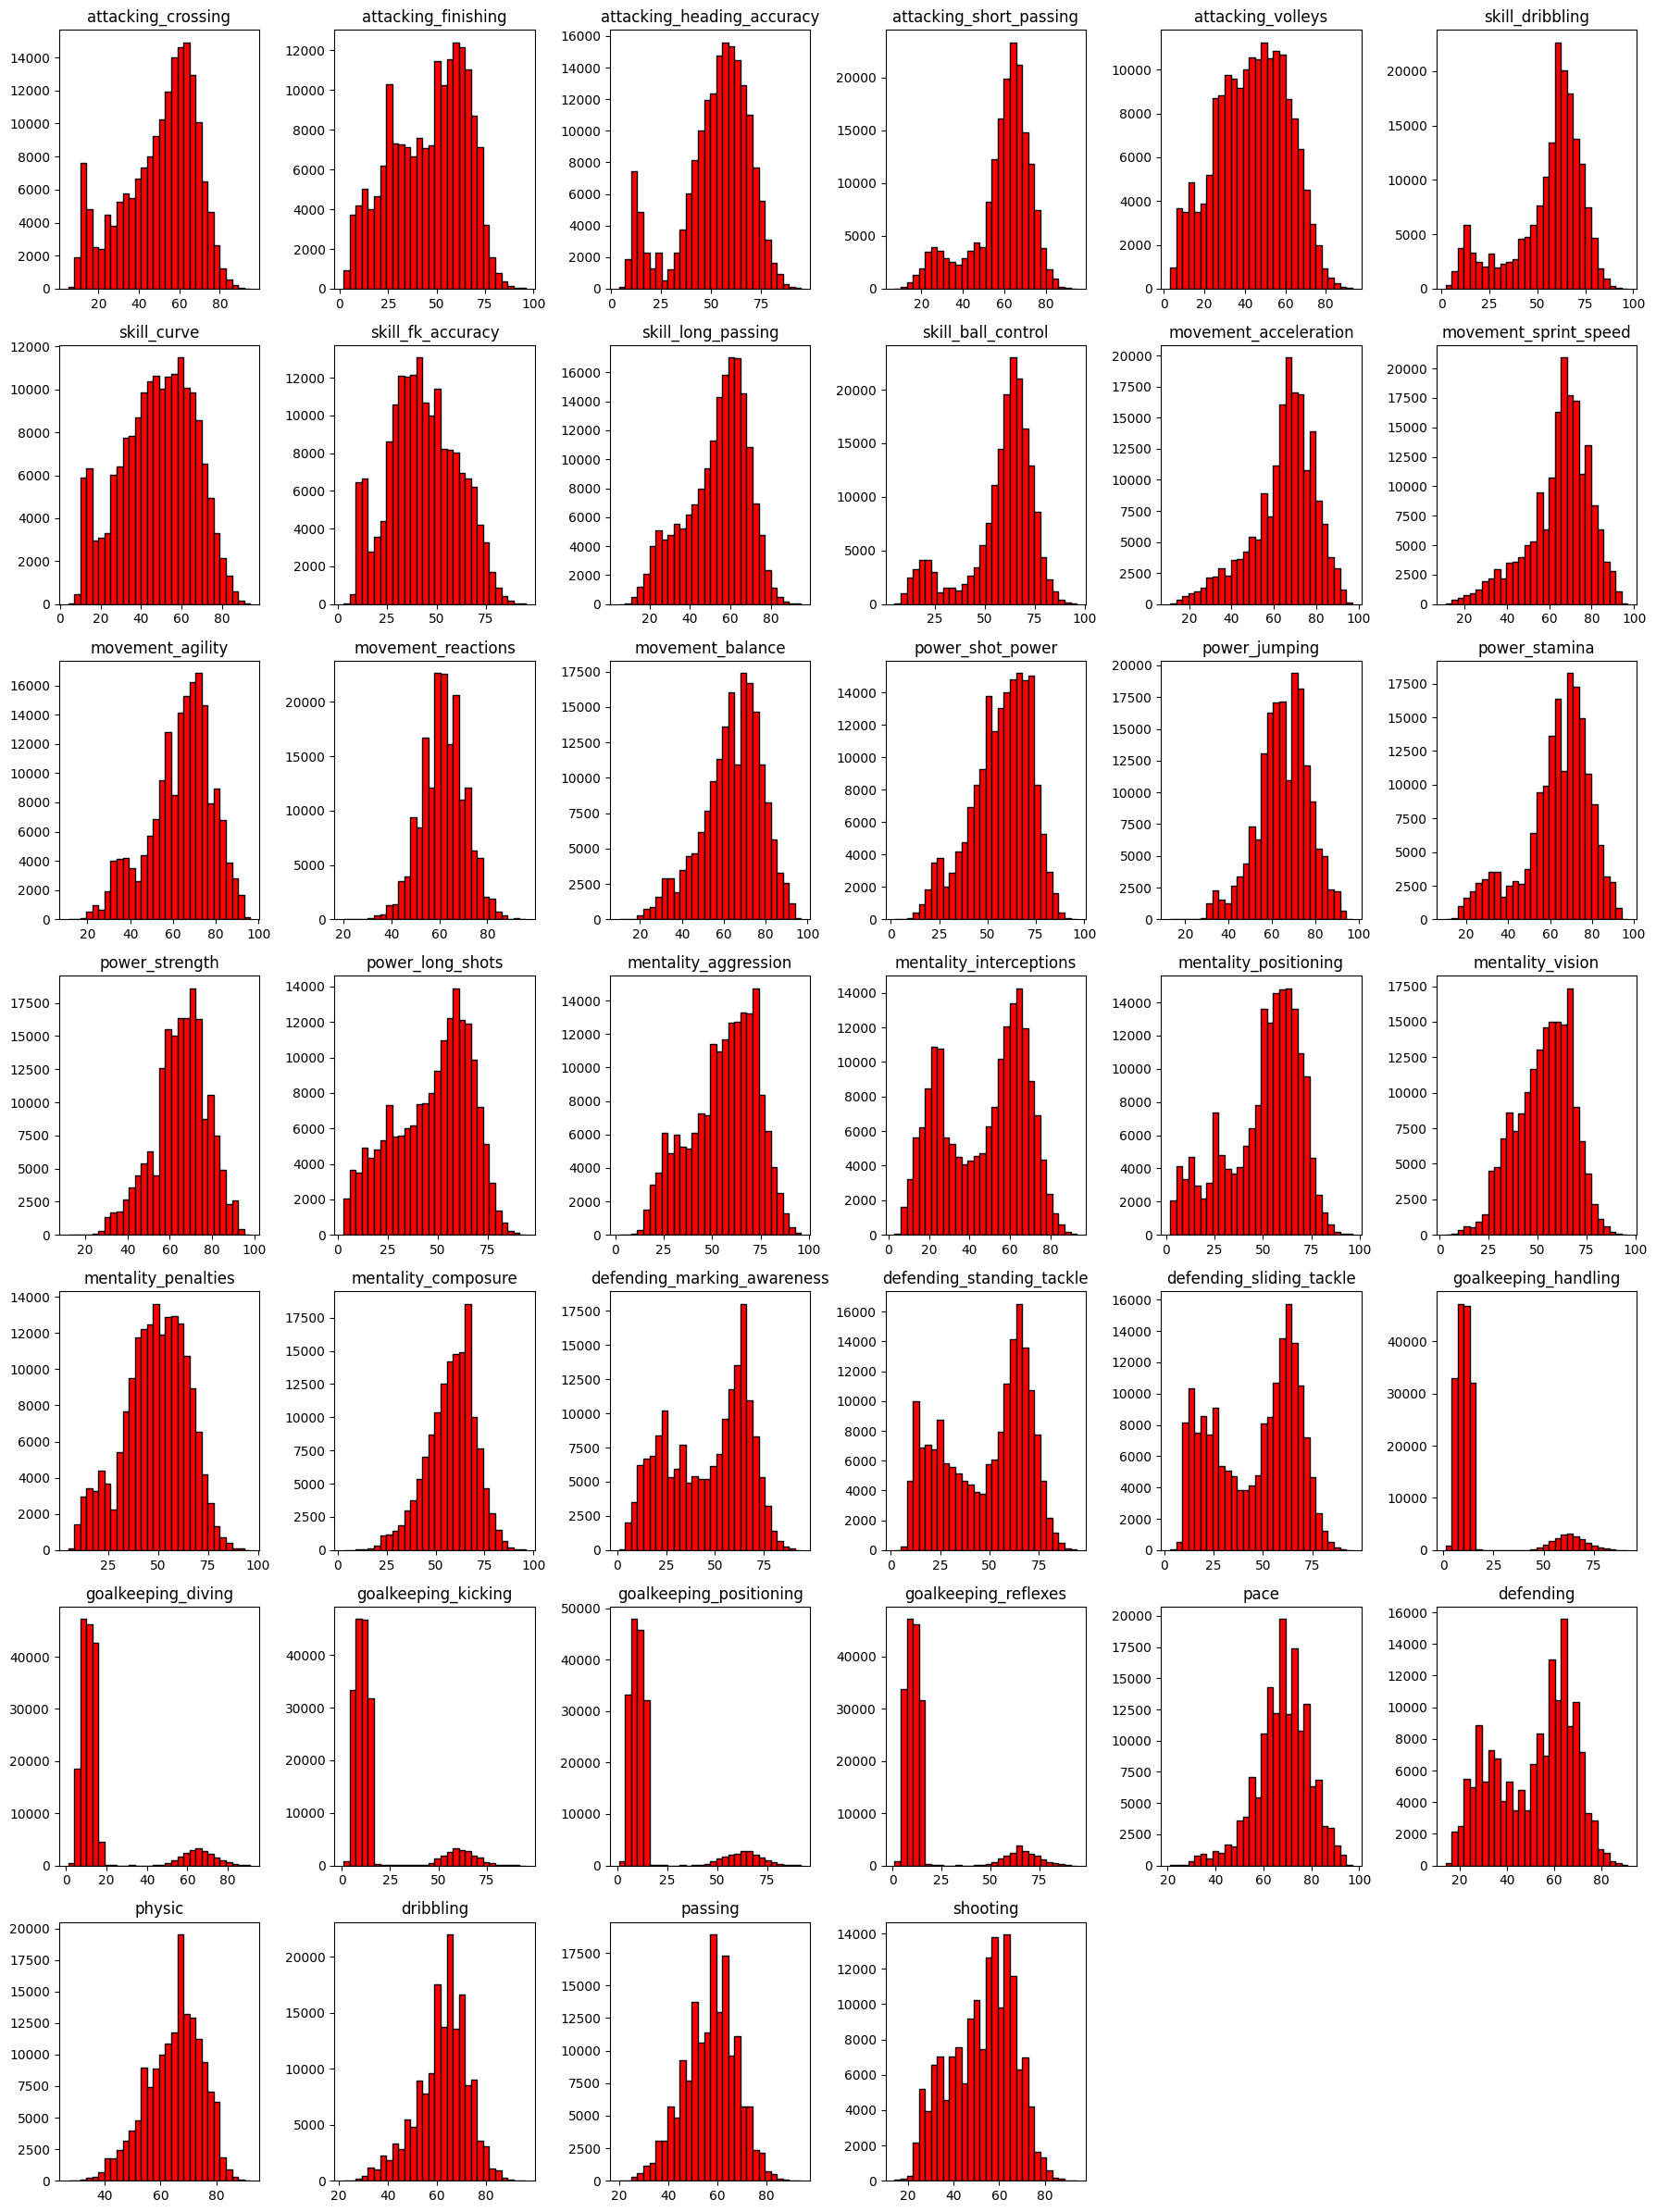

In [33]:
df_skills.hist(figsize=(18, 24), bins=30, color='red', edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

In [34]:
data_filtered['principal_position'] = data_filtered['player_positions'].str.split(',').str[0].str.strip()

# Diccionario de mapeo
pos_map = {
    **{p: 'Forward' for p in forwards},
    **{p: 'Midfielder' for p in midfielders},
    **{p: 'Defender' for p in defenders},
    **{p: 'GK' for p in goalkeepers}
}

# Aplicar el mapeo directamente
data_filtered['position'] = data_filtered['principal_position'].map(pos_map).fillna('nan')
data_filtered['position'].value_counts()

,count
position,
Midfielder,17258
Defender,15293
Forward,9354
GK,5367


In [36]:
categorical_cols = ['nationality_name','preferred_foot','weak_foot','skill_moves',
                   'work_rate','body_type','position']

def graficar_categoricas(df, cat_cols, top_n=10):
    n = len(cat_cols)
    if n == 0:
        return

    fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(cat_cols):
        # astype(str) homogeneiza números y texto. sort_values pone la barra más alta arriba.
        counts = (
            df[col]
            .astype(str)
            .value_counts(dropna=False)
            .head(top_n)
            .sort_values(ascending=True)
        )

        counts.plot(kind="barh", ax=axes[i], color="#4C72B0", edgecolor="black")
        axes[i].set_title(f"Distribución: {col}", fontweight="bold")
        axes[i].set_xlabel("Conteo")
        axes[i].grid(axis="x", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

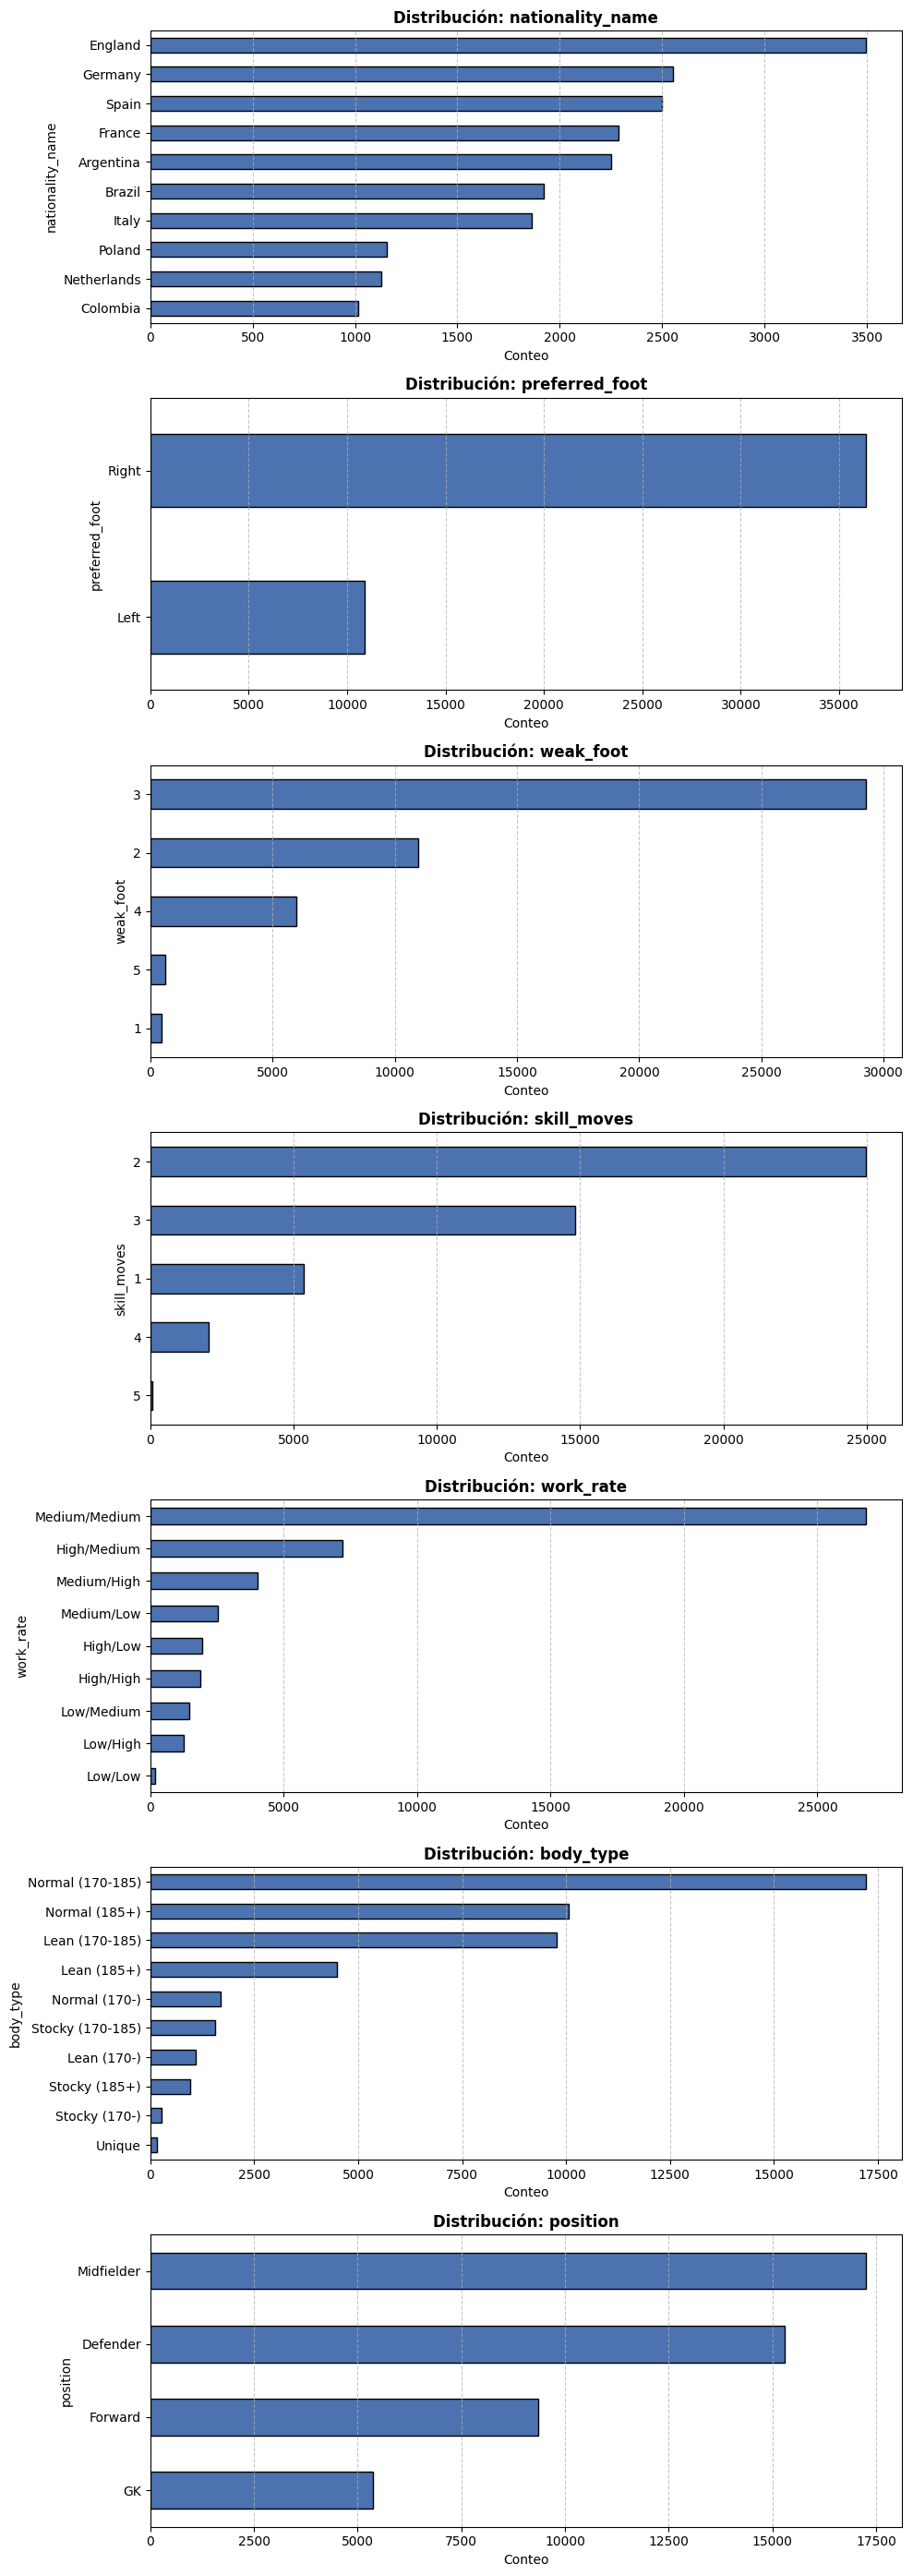

In [37]:
graficar_categoricas(data_filtered, categorical_cols, top_n=10)